# Imports

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
import numpy as np
import subprocess
import pandas as pd
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
#from sklearn.feature_extraction.text import CountVectorizer  #DT does not take strings as input for the model fit step....
from IPython.display import Image
#import pydotplus as pydot
from sklearn import tree
warnings.filterwarnings('ignore')


# Data Cleaning

In [22]:
from google.colab import drive

drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/Machine Learning/FINAL PROJECT/my_training_data(in).csv'
data = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
data.shape

(1195, 73)

In [24]:
print(data['label2'].unique())

['attack' 'benign']


In [25]:
labels_dict={'attack':1, 'benign':0}
data['label2'] = data['label2'].map(labels_dict)


In [26]:
data.shape

(1195, 73)

# Getting Data (Splitting for Train and Test)




In [27]:
data = data.dropna()
data = data.drop('label', axis=1)
data.head()

,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_header-length_avg,network_header-length_max,network_header-length_min,network_header-length_std_deviation,network_fragmented-packets,network_fragmentation-score,...,network_packets_dst_count,network_interval-packets,log_messages_count,log_data-ranges_avg,log_data-ranges_max,log_data-ranges_min,log_data-ranges_std_deviation,log_data-types_count,timeDurationInSeconds,label2
0,63.000000,64.0,62.0,1.000017,20.0,20.0,20.0,0.0,0,0,...,14750,3108.335228,29500,0,0,0,0,0,10,1
1,62.999877,64.0,61.0,1.000246,20.0,20.0,20.0,0.0,0,0,...,4065,914.745196,8133,0,0,0,0,0,10,1
2,62.675676,64.0,62.0,0.949158,20.0,20.0,20.0,0.0,0,0,...,98,30.766254,148,0,0,0,0,0,10,1
3,63.000000,64.0,62.0,1.000023,20.0,20.0,20.0,0.0,0,0,...,11080,2500.940731,22160,0,0,0,0,0,10,1
5,62.857143,64.0,62.0,1.069045,20.0,20.0,20.0,0.0,0,0,...,4,0.707193,7,0,0,0,0,0,10,1


In [28]:
data = data.dropna()
X = data.drop('label2', axis=1)
Y = data.pop('label2')
x_train, x_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size=0.3,
                                                    random_state=123,
                                                    shuffle=True)

In [29]:
def getAccuracy(testSet, predictions):
  correct = sum(1 for a, b in zip(testSet, predictions) if a==b)
  return (correct/float(len(testSet)))*100.0


In [30]:
import pandas as pd
import numpy as np
from sklearn import svm, metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import string
%matplotlib inline

## Hyperparameter Tunning

In [15]:
C_values = [0.1, 1, 3, 10]
gamma_values = [0.001, 0.01, 0.025, 0.1]
results = []
for C in C_values:
    for gamma in gamma_values:
        clf = svm.SVC(C=C, gamma=gamma)
        clf.fit(x_train, y_train)
        y_pred = clf.predict(x_test)
        acc = getAccuracy(y_test, y_pred)
        results.append((C, gamma, acc))
        print(f"C={C:5}, gamma={gamma:.3f}  →  Accuracy: {acc:.2f}%")

C=  0.1, gamma=0.001  →  Accuracy: 77.23%
C=  0.1, gamma=0.010  →  Accuracy: 77.23%
C=  0.1, gamma=0.025  →  Accuracy: 77.23%
C=  0.1, gamma=0.100  →  Accuracy: 77.23%
C=    1, gamma=0.001  →  Accuracy: 87.32%
C=    1, gamma=0.010  →  Accuracy: 85.01%
C=    1, gamma=0.025  →  Accuracy: 84.73%
C=    1, gamma=0.100  →  Accuracy: 83.57%
C=    3, gamma=0.001  →  Accuracy: 87.61%
C=    3, gamma=0.010  →  Accuracy: 85.59%
C=    3, gamma=0.025  →  Accuracy: 85.01%
C=    3, gamma=0.100  →  Accuracy: 83.86%
C=   10, gamma=0.001  →  Accuracy: 87.61%
C=   10, gamma=0.010  →  Accuracy: 85.88%
C=   10, gamma=0.025  →  Accuracy: 85.01%
C=   10, gamma=0.100  →  Accuracy: 83.86%


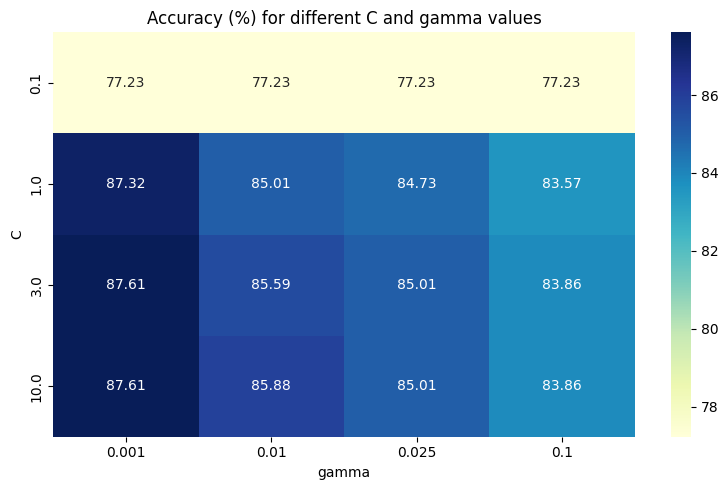

In [17]:
acc_matrix = np.array([r[2] for r in results]).reshape(len(C_values), len(gamma_values))
df_results = pd.DataFrame(acc_matrix, index=C_values, columns=gamma_values)

plt.figure(figsize=(8, 5))
sns.heatmap(df_results, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Accuracy (%) for different C and gamma values')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

In [15]:
clf = svm.SVC(kernel='linear', C=3, gamma=0.025)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
acc = getAccuracy(y_test, y_pred)
linearResults = acc

In [16]:
clf = svm.SVC(kernel='rbf', C=3, gamma=0.025)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
acc = getAccuracy(y_test, y_pred)
rgfResults = acc

In [17]:
clf = svm.SVC(kernel='sigmoid', C=3, gamma=0.025)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
acc = getAccuracy(y_test, y_pred)
sigResults = acc

In [ ]:
clf = svm.SVC(kernel='poly', C=3, gamma=0.025)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
acc = getAccuracy(y_test, y_pred)
polyResults = acc

In [ ]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = {}

for kernel in kernels:

    kernel_results[kernel] = acc
    print(f"Kernel: {kernel:8}  →  Accuracy: {acc:.2f}%")

Kernel: linear    →  Accuracy: 95.10%


In [18]:
print(f'Kernel: linear, -> accuracy:{linearResults}')
print(f'Kernel: RGB, -> accuracy:{rgfResults}')
print(f'Kernel: sigmoid -> accuracy:{sigResults}')

Kernel: linear, -> accuracy:93.14285714285714
Kernel: RGB, -> accuracy:84.0
Kernel: sigmoid -> accuracy:78.28571428571428


# So Kernel = Linear is the best kernel type

# Hyper Parameter Searching for Best Values (with scikit-learn)

In [44]:
from sklearn.svm import SVC
print("LINEAR")
model = SVC(kernel='linear')
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(classification_report(y_test, predictions))
print("-"*50)
print("RBF")
model = SVC(kernel='rbf')
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(classification_report(y_test, predictions))
print("-"*50)
print("sigmoid")
model = SVC(kernel='sigmoid')
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(classification_report(y_test, predictions))
print("-"*50)
print("poly")
model = SVC(kernel='poly')
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(classification_report(y_test, predictions))

LINEAR
              precision    recall  f1-score   support

           0       0.88      0.91      0.89        79
           1       0.97      0.96      0.97       268

    accuracy                           0.95       347
   macro avg       0.93      0.94      0.93       347
weighted avg       0.95      0.95      0.95       347

--------------------------------------------------
RBF
              precision    recall  f1-score   support

           0       0.86      0.08      0.14        79
           1       0.79      1.00      0.88       268

    accuracy                           0.79       347
   macro avg       0.82      0.54      0.51       347
weighted avg       0.80      0.79      0.71       347

--------------------------------------------------
sigmoid
              precision    recall  f1-score   support

           0       0.60      0.08      0.13        79
           1       0.78      0.99      0.87       268

    accuracy                           0.78       347
   macr

In [46]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.1, 1, 10, 100, 1000],
			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
			'kernel': ['linear']}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
grid.fit(x_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.951 total time=  18.5s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.944 total time=   4.3s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.950 total time=   7.3s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.981 total time=   5.8s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.925 total time=  12.0s
[CV 1/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.951 total time=  11.7s
[CV 2/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.944 total time=  10.4s
[CV 3/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.950 total time=  12.6s
[CV 4/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.981 total time=   8.8s
[CV 5/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.925 total time=  10.4s
[CV 1/5] END ..C=0.1, gamma=0.01, kernel=linear;, score=0.951 total time=  16.0s
[CV 2/5] END ..C=0.1, gamma=0.01, kernel=linear

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['linear']},
             verbose=3)

In [50]:
print(grid.best_params_)
model = SVC(kernel='linear', C=100, gamma = 1)
model.fit(x_train, y_train)
predictions = model.predict(x_test)
print(classification_report(y_test, predictions))

{'C': 100, 'gamma': 1, 'kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.91      0.87      0.89        79
           1       0.96      0.97      0.97       268

    accuracy                           0.95       347
   macro avg       0.94      0.92      0.93       347
weighted avg       0.95      0.95      0.95       347



In [ ]:
# param_grid = {'C': [0.1, 1, 10, 100, 1000],
# 			'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
# 			'kernel': ['linear','poly','rbf','sigmoid']}
# grid2 = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
# grid2.fit(x_train, y_train)
# print(grid2.best_params)

# Summary
`Accuracy = 0.95` with `{'C': 100, 'gamma': 1, 'kernel': 'linear'}`